# Parallel Workflow: UPSC Essay Analysis

## Overview

This notebook demonstrates the **Parallel Workflow Pattern** using LangGraph for UPSC essay evaluation. Multiple aspects of the essay are analyzed independently and simultaneously, and the results are aggregated to generate an overall assessment and score.

---

## State Definition

The workflow maintains the following state:

* `essay` – Essay submitted for evaluation
* `language_feedback` – Feedback on grammar, vocabulary, and language usage
* `analysis_feedback` – Feedback on depth of analysis and critical thinking
* `clarity_feedback` – Feedback on structure, coherence, and readability
* `overall_feedback` – Consolidated evaluation of the essay
* `individual_score` – Scores generated by individual evaluation nodes
* `average_score` – Final average score calculated from all evaluations

---

## Workflow Diagram

```text
                      Essay
                        │
                        ▼
        ┌───────────────┼───────────────┐
        │               │               │
        ▼               ▼               ▼
   Language        Analysis         Clarity
   Evaluation      Evaluation      Evaluation
        │               │               │
        ▼               ▼               ▼
  Feedback +      Feedback +      Feedback +
     Score           Score           Score
        │               │               │
        └───────────────┼───────────────┘
                        │
                        ▼
                Aggregate Results
                        │
                        ▼
              Calculate Average Score
                        │
                        ▼
             Generate Overall Feedback
                        │
                        ▼
                    Final State
```

---

## Parallel Workflow Characteristics

* Independent evaluators analyze the same essay simultaneously.
* No dependency exists between language, analysis, and clarity evaluations.
* Scores are merged using state reducers.
* Feedback is aggregated before generating the final assessment.
* Enables scalable and efficient multi-criteria essay evaluation.

---

## Expected Output

The final state contains:

* Language feedback
* Analysis feedback
* Clarity feedback
* Individual evaluation scores
* Average score
* Overall feedback

This workflow demonstrates how parallel execution can be used to evaluate multiple dimensions of a UPSC essay simultaneously and produce a comprehensive assessment.


In [70]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import operator
from dotenv import load_dotenv

In [71]:
load_dotenv()

True

In [72]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [73]:
class EvaluationSchema(BaseModel):
    score: int = Field(description="Score out of 10", ge=0, le=10)
    feedback: str = Field(description="Detailed feedback for this essay")

In [74]:
structured_model = model.with_structured_output(EvaluationSchema)

In [75]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int], operator.add]
    average_score: float

In [76]:
def evaluate_language(state: UPSCState):
    prompt = f"Evaluate the LANGUAGE QUALITY of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {
        "language_feedback": output.feedback,
        "individual_score": [output.score]
    }

In [77]:
def evaluate_analysis(state: UPSCState):
    prompt = f"Evaluate the DEPTH OF ANALYSIS of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {
        "analysis_feedback": output.feedback,
        "individual_score": [output.score]
    }

In [78]:
def evaluate_thought(state: UPSCState):
    prompt = f"Evaluate the CLARITY OF THOUGHT of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {
        "clarity_feedback": output.feedback,
        "individual_score": [output.score]
    }

In [79]:
def final_evaluation(state: UPSCState):
    prompt = f"Based on the following feedbacks create a summarized feedback \n language feedback {state['language_feedback']} \n depth of analysis feedback {state['analysis_feedback']} \n clarity of thought feedback {state['clarity_feedback']}"
    output = model.invoke(prompt)

    avg_score = sum(state['individual_score'])/len(state['individual_score'])
    
    return {
        "overall_feedback": output.content,
        "average_score": avg_score
    }

In [80]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

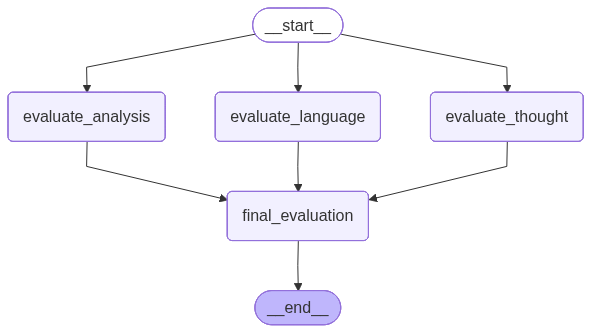

In [81]:
workflow

In [82]:
essay = """
# Technology as the Silent Architect of Modern Civilization

## Introduction

Human civilization has progressed through a series of transformative revolutions—from the discovery of fire to the invention of the wheel, from the industrial revolution to the digital age. At every stage, technology has acted as a powerful catalyst of change. Today, technology is no longer merely a tool; it has become the silent architect shaping economies, governance, social relations, education, healthcare, and even human thought. While its influence often operates in the background, its impact on modern civilization is profound and far-reaching.

## Technology and Economic Transformation

The modern global economy is fundamentally driven by technological innovation. Automation, artificial intelligence, cloud computing, and digital platforms have revolutionized production and service delivery. Businesses can now operate across continents, and startups can reach global markets with minimal physical infrastructure.

Technology has also democratized entrepreneurship by reducing barriers to entry. Digital payment systems, e-commerce platforms, and online marketplaces have empowered small businesses and individuals. In countries like India, initiatives such as Digital India and UPI have transformed financial inclusion and economic participation.

However, technological advancement has also raised concerns about job displacement, skill gaps, and economic inequality. The challenge lies in ensuring that technological growth remains inclusive and benefits all sections of society.

## Technology and Governance

Governments across the world increasingly rely on technology for efficient administration and public service delivery. Digital governance enhances transparency, accountability, and citizen participation. Online portals, digital identity systems, and data-driven policymaking have improved access to welfare schemes and public services.

Technology has also strengthened disaster management, public health surveillance, and law enforcement. During crises such as pandemics, digital tools played a crucial role in information dissemination and service coordination.

At the same time, concerns regarding privacy, surveillance, and data security have emerged. Balancing technological efficiency with individual rights remains one of the defining governance challenges of the twenty-first century.

## Technology and Social Change

Social interactions have been fundamentally reshaped by technology. Social media platforms connect people across geographical boundaries, enabling the exchange of ideas and cultural interaction on an unprecedented scale.

Technology has amplified voices that were previously marginalized and has facilitated social movements around issues such as gender equality, environmental protection, and human rights. Information is now more accessible than ever before, contributing to greater awareness and empowerment.

Yet, technology has also contributed to misinformation, polarization, and declining attention spans. The rapid spread of false information can undermine social harmony and democratic processes. Thus, society must cultivate digital literacy alongside technological advancement.

## Technology in Education and Healthcare

Education has witnessed a paradigm shift due to technological integration. Online learning platforms, digital libraries, and virtual classrooms have expanded access to knowledge. Students from remote regions can now access quality educational resources that were once limited to urban centers.

Similarly, healthcare has been transformed through telemedicine, robotic surgery, electronic health records, and AI-assisted diagnostics. Technology enables faster disease detection, improved treatment outcomes, and greater accessibility to healthcare services.

The COVID-19 pandemic highlighted the importance of technological infrastructure in maintaining continuity in both education and healthcare. However, the digital divide remains a significant obstacle that must be addressed to ensure equitable access.

## Ethical Challenges of Technological Advancement

While technology offers immense benefits, it also raises complex ethical questions. Artificial intelligence challenges traditional notions of accountability and decision-making. Genetic engineering and biotechnology raise concerns regarding the limits of human intervention in nature.

Furthermore, excessive dependence on technology may weaken human relationships, critical thinking, and emotional well-being. Cybercrime, identity theft, and data breaches demonstrate that technological progress is accompanied by new vulnerabilities.

Therefore, ethical frameworks and regulatory mechanisms must evolve alongside technological innovation to ensure that progress remains aligned with human values.

## Sustainable Development and Technology

Technology plays a crucial role in addressing global challenges such as climate change, resource scarcity, and environmental degradation. Renewable energy technologies, smart agriculture, electric mobility, and sustainable urban planning contribute to ecological sustainability.

Scientific innovation enables societies to optimize resource utilization while minimizing environmental impact. Green technologies represent the possibility of harmonizing economic development with environmental conservation.

However, the environmental costs of technological production and electronic waste must also be considered. Sustainable innovation should focus not only on efficiency but also on long-term ecological responsibility.

## Conclusion

Technology is undeniably one of the most influential forces shaping modern civilization. It drives economic growth, strengthens governance, transforms education and healthcare, and connects societies in unprecedented ways. Yet, technology itself is neither inherently good nor bad; its impact depends on how humanity chooses to develop and utilize it.

The future of civilization will not be determined solely by technological capability but by the wisdom with which technology is governed. As the silent architect of modern civilization, technology must remain guided by ethical principles, inclusivity, sustainability, and human welfare. Only then can it serve as a force for comprehensive and equitable progress.
"""

In [89]:
initial_state = {
    "essay": essay
}

final_state = workflow.invoke(initial_state)

In [90]:
print(final_state)

{'essay': '\n# Technology as the Silent Architect of Modern Civilization\n\n## Introduction\n\nHuman civilization has progressed through a series of transformative revolutions—from the discovery of fire to the invention of the wheel, from the industrial revolution to the digital age. At every stage, technology has acted as a powerful catalyst of change. Today, technology is no longer merely a tool; it has become the silent architect shaping economies, governance, social relations, education, healthcare, and even human thought. While its influence often operates in the background, its impact on modern civilization is profound and far-reaching.\n\n## Technology and Economic Transformation\n\nThe modern global economy is fundamentally driven by technological innovation. Automation, artificial intelligence, cloud computing, and digital platforms have revolutionized production and service delivery. Businesses can now operate across continents, and startups can reach global markets with mini